<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana C. Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago A. Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>Edição:</b> 2/2021 | <b>Editora:</b> LTC</div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2021 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Modelos Múltiplos em Agrupamento - Evidence Accumulation Clustering</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>

 <hr style="height:2px"> 

## Introdução

Agrupamento de dados é uma tarefa importante, mas extremamente difícil. Tendo como objetivo principal a identificação de padrões e estruturas dentro de um conjunto de dados não-rotulados, muitos algoritmos foram desenvolvidos pra área.

Como mostrado no _notebook_ **Algoritmos de Agrupamento e Validação**, cada um destes algoritmos existentes possuem suas características e técnicas de agrupamento específicas. As estruturas identificadas por dois algoritmos com abordagens diferentes podem ser (e povavelmente serão) bastante diferentes. Em cenários reais, onde os conjuntos de dados não possuem rótulos, torna-se bastante complexo avaliar qual o melhor agrupamento obtido, ainda mais quando não há conhecimento do domínio do problema.

Observando este cenário, muitas técnicas foram propostas para combinar múltiplos algoritmos de agrupamento, criando _ensembles_ de algoritmos. Estas técnicas, também chamadas de algoritmos híbridos, aproveitam o fato de que cada algoritmo simples encontra tipos de estruturas específicas nos dados, para gerar um agrupamento mais completo.

Neste *notebook*, será vista a técnica de **Evidence Accumulation-based Clustering (EAC)**, apresentada por **Fred & Jain [1, 2]**. Nela, uma série de agrupamentos são gerados através do método de K-Médias, para depois serem combinados em um agrupamento final através de algum algoritmo hierárquico. Será realizado um estudo da técnica sobre a base de dados `spirals`, mostrando como as estruturas reais do conjunto podem ser descobertas através da junção de múltiplos métodos de agrupamento. 

Espera-se que ao longo do experimento, o leitor compreenda com clareza a EAC, e entenda o conceito e importância de modelos múltiplos em agrupamento. Ao final do *notebook*, espera-se que o leitor visualize a possível superioridade que modelos múltiplos podem alcançar quando comparados a métodos de agrupamento simples, e realize experimentos próprios para aprender mais sobre o assunto.

Este _notebook_ se refere ao Capítulo **14 (Modelos Múltiplos Descritivos)** e aos artigos **Data clustering Using Evidence Accumulation** [2] e **Combining multiple clusterings using Evidence Accumulation** [3].

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/3.1.1/index.html) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scipy`](https://www.scipy.org) (versão 1.2.1 ou superior): conjunto de funções úteis para Ciência de Dados
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 0.22.2 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial

A biblioteca [`os`](https://docs.python.org/3/library/os.html), para realizar tarefas específicas ao Sistema Operacional, também será utilizada. Por fazer parte da [Biblioteca Padrão de Python](https://docs.python.org/pt-br/3/library/), sua instalação não é necessária.

Serão utilizados também os conjuntos de dados disponibilizados junto com este *notebook*, que se encontram no diretório `datasets`, em formato de arquivo `.csv`.

In [1]:
# -*- coding: utf-8 -*-

from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering, KMeans
%matplotlib inline

DATASETS_DIR = 'datasets'

---
## Funções auxiliares

Nesta célula, estão implementadas diversas funções que serão utilizadas repetidamente ao longo do _notebook_. São elas:

**`colorize`**: recebe um vetor de rótulos (`data`) em formato de `list` ou `numpy.ndarray` e retorna um vetor de códigos HTML para cores em `numpy.ndarray`, para ser usado nos gráficos. **Obs**.: embora bibliotecas de gráficos, como a `matplotlib`, disponibilizem maneiras de colorir seus gráficos, suas paletas de cores não são adequadas para daltonismo. A função contorna este problema;

**`load_dataset`**: recebe o nome de um dos conjuntos de dados de _datasets_ (`dataset_name`) em formato `str` e carrega como um objeto do tipo `pandas.DataFrame`;

**`plot_multiple_partitions`**: recebe uma base de dados (`dataset`) em formato `pandas.DataFrame` e múltiplas partições (`cluster_labels`) em `list` ou `numpy.ndarray`, e gera o gráfico de cada uma destas partições. A disposição dos gráficos deve ser definida através de `nrows` (qt. de linhas) e `ncols` (qt. de colunas). Pode receber um título geral (`suptitle`) e títulos específicos por gráfico (`subtitles`);

**`plot_single_heatmap`**: recebe uma matriz numérica (`heatmap`) em formato `numpy.ndarray` e gera uma imagem de mapa de calor em tons de cinza. Pode receber um título (`title`);

**`plot_multiple_heatmaps`**: recebe múltiplas matrizes numéricas (`heatmaps`) em formato `numpy.ndarray` e gera uma imagem de múltiplos mapas de calor em tons de cinza, um para cada matriz. Possui parâmetros iguais a função `plot_multiple_partitions`.

In [2]:
def colorize(data, fixed_color=False):
    color_palette = ['#910101', '#036CD7', '#078F8F', '#000000', '#FDFD6F', '#B16FFD', '#22FF25',
                     '#074752', '#8F4A00', '#FE6FB5', '#6BB6FE', '#DF6B00', '#48018D', '#FCB5DA']
    labels = np.unique(data)
    if len(labels) > len(color_palette):
        np.random.seed(1)
        color_palette += ["#%06x" % c for c in np.random.randint(0, 0xFFFFFF, len(labels)-len(color_palette))]
    color_array = np.empty(data.shape, dtype=object)
    for label, color in zip(labels, color_palette):
        color_array[np.where(data==label)] = color
    return color_array


def load_dataset(dataset_name):
    dataset = pd.read_csv(os.path.join(DATASETS_DIR, dataset_name+'.csv'), sep=';')
    dataset.name = dataset_name
    dataset.n_clusters = dataset['cluster'].nunique()
    return dataset
    
    
def plot_multiple_partitions(dataset, cluster_labels, nrows, ncols, suptitle=None, subtitles=None):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(min(5*ncols, 12), 3.5*nrows), constrained_layout=True)
    ax = ax.flatten()
    for i, clusters in enumerate(cluster_labels):        
        ax[i].scatter(dataset['d1'], dataset['d2'], s=10, c=colorize(clusters))            
        if subtitles is not None:
            ax[i].set_title(subtitles[i])
        ax[i].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=16)
    plt.show()
    
    
def plot_single_heatmap(heatmap, title=None):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3.5), constrained_layout=True)
    ax.imshow(heatmap, cmap=cm.gray)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    if title is not None:
        ax.set_title(title, fontsize=16)    
    plt.show()
    
    
def plot_multiple_heatmaps(heatmaps, nrows, ncols, suptitle=None, subtitles=None):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(min(5*ncols, 12), 3.5*nrows), constrained_layout=True)
    ax = ax.flatten()
    for i, heatmap in enumerate(heatmaps):
        ax[i].imshow(heatmap, cmap=cm.gray)
        if subtitles is not None:
            ax[i].set_title(subtitles[i])
        ax[i].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=16)
    plt.show()

### O problema

Para entender o funcionamento da técnica **Evidence Accumulation-base Clustering (EAC)**, será realizada uma aplicação da mesma sobre a base de dados **_spirals_**, presente no arquivo `datasets/spirals.csv`.

Como visto no _notebook_ **Algoritmos de Agrupamento e Validação**, o algoritmo K-Médias não consegue encontrar as estruturas reais do conjunto de dados. Por se tratar de um algoritmo particional baseado em erro quadrático e centróides, o método por si só não é capaz de encontrar as duas estruturas encadeadas que compõe a base. Entretanto, com **EAC**, é possível obter um resultado diferente e bastante interessante.

Inicialmente, é bom relembrar que a estrutura real desse conjunto possui 2 *clusters*, e qual é a estrutura obtida com uma execução simples do algoritmo K-Médias, para $k = 2$.

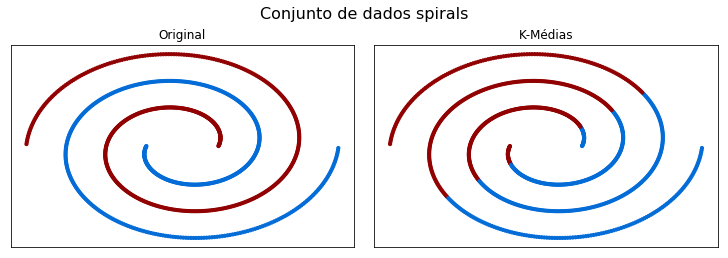

In [3]:
dataset = load_dataset('spirals')

model = KMeans(n_clusters=dataset.n_clusters)
kmean_clusters = model.fit_predict(dataset[['d1', 'd2']])
plot_multiple_partitions(
    dataset[['d1', 'd2']], cluster_labels=[dataset['cluster'], kmean_clusters], 
    nrows=1, ncols=2, suptitle='Conjunto de dados {}'.format(dataset.name), subtitles=['Original', 'K-Médias']
)

---
## Evidence Accumulation-based Clustering

A técnica **Evidence Accumulation-based Clustering (EAC)**, proposta por **Fred & Jain [1, 2]**, possui uma abordagem _split and merge_. Nela, um mesmo algoritmo de agrupamento é executado diversas vezes, variando os parâmetros de entrada, criando diversas partições com um número grande de _clusters_ pequenos, que representam as evidências que serão combinadas para a produção do agrupamento (ou partição) final. Em seguida, algum método é aplicado para combinar estes _clusters_ no agrupamento final.

Fred & Jain [2] propõem o uso do algoritmo K-Médias para gerar as múltiplas partições diferentes. A escolha é justificada pela simplicidade e velocidade do método, permitindo diversas execuções seguidas em um curto período de tempo e demandando baixo esforço computacional.

Com as diferentes partições geradas, é construída uma matriz de coassociação entre todas as amostras do conjunto, armazenando a quantidade de partições em que cada par de amostras foi agrupado no mesmo _cluster_. A ideia desta matriz, que serve como base para a EAC, é de que amostras agrupadas diversas vezes no mesmo _cluster_ tenderão a, de fato, pertencer ao mesmo _cluster_ real.

Por fim, um algoritmo hierárquico é aplicado sobre a matriz de coassociação, gerando a partição final. Em Fred & Jain [3], os autores utilizaram os métodos _Single-link_ e *Average-link*, com cada um se saindo melhor que o outro de acordo com as características da base de dados.

A EAC é dividida em três etapas: **_split_**, **_combine_** e **_merge_**, que encontram-se abordadas de forma individual nas células seguintes.

---
## 1. _Split_

Na etapa de **_split_**, são produzidas $N$ partições do conjunto de dados, a partir de múltiplas execuções do método K-Médias. Cada execução é realizada com parâmetros de inicialização aleatórios, capturando assim $N$ partições diferentes entre si. Essa fase também pode ser considerada como a fase de acúmulo das evidências sobre os _clusters_ presentes nos dados.

A escolha de $N$ é empírica, com os autores tendo testado $N = 100$ e $N = 200$ e obtido resultados semelhantes [3]. Neste experimento, devido ao baixo esforço computacional para execução do K-Médias na base `spirals`, foi adotado $N = 200$, como feito em Fred & Jain [2].

Nesta etapa, os autores apresentam duas abordagens diferentes que podem ser adotadas:
- **Algoritmo 1**: O valor de $K$ para o K-Médias é fixado entre todas as $N$ execuções, gerando partições de mesmo número de _clusters_;
- **Algoritmo 2**: Para cada uma das $N$ execuções, o valor de $K$ é escolhido aleatoriamente, gerando partições de números de _clusters_ diferentes.

Para escolher $K$, seja o valor fixo ou o intervalo de valores para a seleção aleatória, os autores sugerem duas estratégias. A primeira, mais simples, trata-se de uma regra de ouro $K = 	\sqrt{n}$, onde $n$ é o número de amostras do conjunto. A segunda corresponde a realizar um método de decomposição de misturas gaussianas [1] sobre a base, atribuindo a $K$ o número de componentes da mistura. 

Devido a sua complexidade, a última estratégia foge do escopo deste *notebook*, sendo então adotada a primeira mencionada. Entretanto, para os interessados, o uso da segunda estratégia é incentivado, existindo classes na biblioteca `scikit-learn` que podem ajudar (`sklearn.mixture.GaussianMixture`).

**Obs.:** é importante perceber que o valor de $K$ escolhido não é igual ao número de _clusters_ real dos dados. Ao contrário, é esperado que $K$ seja bem maior que este número, para que a técnica seja efetiva. Para sua melhor compreensão da influência desses parâmetros, $N$ e $K$, faça testes com outros valores menores que os utilizados. Eles fazem toda a diferença para a obtenção das evidências suficientes para a recuperação da estrutura real presente nos dados.

In [4]:
N = 200
K = int(np.sqrt(len(dataset)))
print('N = {}  |  K = {}'.format(N, K))

N = 200  |  K = 31


### Algoritmo I: $N$ inicializações aleatórias com $K$ fixo

$N$ partições do conjunto de dados foram obtidas com o K-Médias, com $K = \sqrt{n}$. Para visualização, foram exibidas as primeiras 8 partições geradas.

**Nota sobre a implementação**: ao utilizar a implementação `KMeans` da biblioteca `scikit-learn`, 3 parâmetros foram definidos (além do número de *clusters*). `init='random'` garante que os centróides iniciais serão escolhidos aleatoriamente; `n_init=1` limita o método a apenas uma execução; `random_state=n` permite que os experimentos sejam reproduzíveis, ao mesmo tempo que garante que cada execução será diferente.

Valor de K para o algoritmo K-Médias: 31



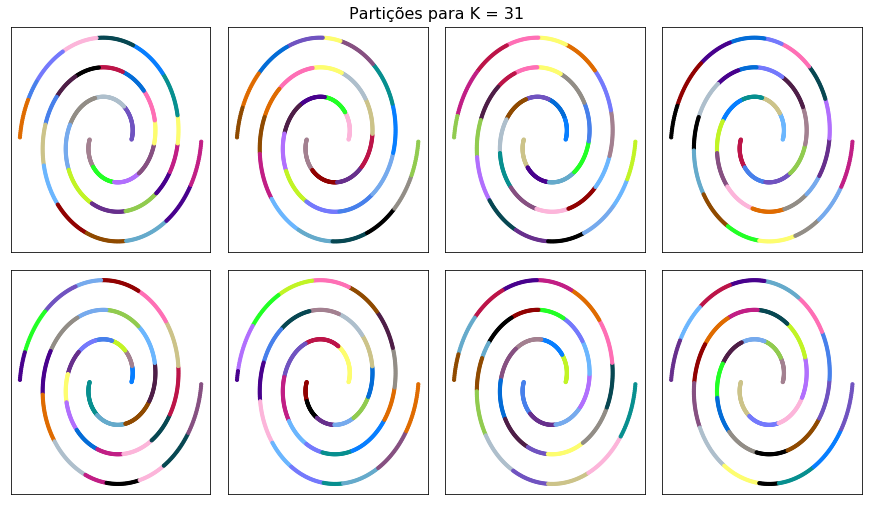

In [5]:
print('Valor de K para o algoritmo K-Médias: {}\n'.format(K))

fixed_k_partitions = list()
for n in range(N):
    print('{:03d}/{:03d} partições produzidas'.format(n+1, N), end='\r', flush=True)
    model = KMeans(n_clusters=K, init='random', n_init=1, random_state=n)
    cluster_labels = model.fit_predict(dataset[['d1', 'd2']])
    fixed_k_partitions.append(cluster_labels)
    
plot_multiple_partitions(dataset[['d1', 'd2']], fixed_k_partitions[:8], nrows=2, ncols=4, 
                         suptitle='Partições para K = {}'.format(K))

### Algoritmo II: $N$ partições com $K$ aleatório

$N$ partições do conjunto de dados foram obtidas com o K-Médias, com $K$ variando entre $[2, \sqrt{n}]$. Para visualização, foram exibidas as primeiras 8 partições geradas.

**Nota sobre a implementação**: semelhante ao Algoritmo I.

Intervalo de variação de K para o algoritmo K-Médias: 2 a 31



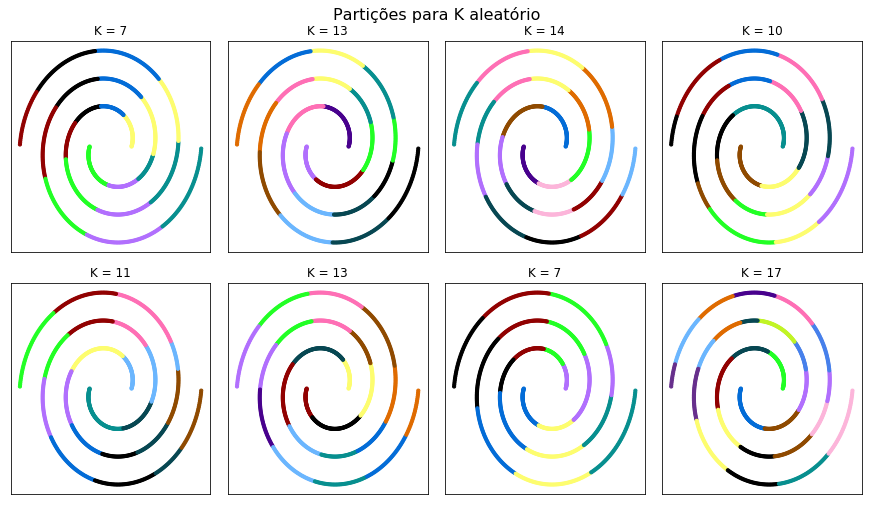

In [6]:
print('Intervalo de variação de K para o algoritmo K-Médias: {} a {}\n'.format(2, K))

np.random.seed(1)
possible_K = np.random.randint(2, K, N)

random_k_partitions = list()
for n, k in zip(range(N), possible_K):
    print('{:03d}/{:03d} partições produzidas'.format(n+1, N), end='\r', flush=True)
    model = KMeans(n_clusters=k, init='random', n_init=1, random_state=n)
    cluster_labels = model.fit_predict(dataset[['d1', 'd2']])
    random_k_partitions.append(cluster_labels)
    
plot_multiple_partitions(
    dataset[['d1', 'd2']], random_k_partitions[:8], nrows=2, ncols=4, 
    suptitle='Partições para K aleatório', subtitles=['K = {}'.format(k) for k in possible_K[:8]]
)

---
## 2. _Combine_

Na etapa de **_combine_**, é construída uma matriz de coassociação entre todas as partições geradas na etapa passada. 

Uma matriz de coassociação é uma matriz $C$ de dimensões $n$ x $n$ (sendo $n$ a quantidade de amostras da conjunto), onde $C_{i,j}$  armazena a quantidade de partições em que a $i$-ésima amostra foi agrupada no mesmo _cluster_ que a $j$-ésima. Após o cálculo da matriz, os elementos são divididos pelo número de partições ($N$), tendo resultado final variando entre 0 (nenhuma partição classificou as amostras juntas) a 1 (todas as partições agruparam as amostras juntas).

Nas células seguintes, foram criadas as matrizes de coassociação para cada um dos dois Algoritmos mencionados na etapa de _split_. Para visualização, foram exibidos os mapas de calor em escala de cinza para as 8 matrizes das 8 primeiras partições, assim como a matriz de coassociação final.

**Obs**.: é interessante perceber como as matrizes de coassociação são bastante diferentes entre os Algoritmos I e II, mostrando o impacto que uma decisão na etapa de _split_ pode causar. Adicionalmente, no Algoritmo II, é interessante perceber como as matrizes de coassociação de cada partição são diferentes entre si, mas todas seguem certos padrões para determinadas amostras.

### Algoritmo I: $N$ inicializações aleatórias com $K$ fixo

Foi calculada a matriz de coassociação das amostras para as partições geradas pelo Algoritmo I.

**Notas sobre a implementação**: embora seja possível gerar uma matriz $n$ x $n$ zerada e percorrer todos os pares de amostras das partições, preenchendo a matriz, isso pode se tornar bastante custoso, com complexidade $O(Nn^2)$. 

Um truque eficiente para realizar esta operação é, para cada partição, replicar o vetor de rótulos até se obter uma matriz quadrada (linha `6`). Em seguida, realizar uma comparação par-a-par do conteúdo da matriz com sua transposta, obtendo assim uma matriz de coassociação binária para aquela partição (linha`7`). Finalmente, basta somar todas as matrizes obtidas para ter a matriz final (linha `10`). Estas operações são realizadas pela biblioteca `numpy` de forma vetorizada, acelerando os cálculos.

Adicionalmente, por questões técnicas das bibliotecas empregadas, foi realizada uma inversão da matriz de coassociação final (linha `15`), para que o conteúdo da matriz passasse a representar distância (quanto menor $C_{i,j}$, mais próximas (maior a coassociação) estão $i$ e $j$). Assim, é possível executar os algoritmos hierárquicos que agrupam as amostras baseado em medidas de distância.

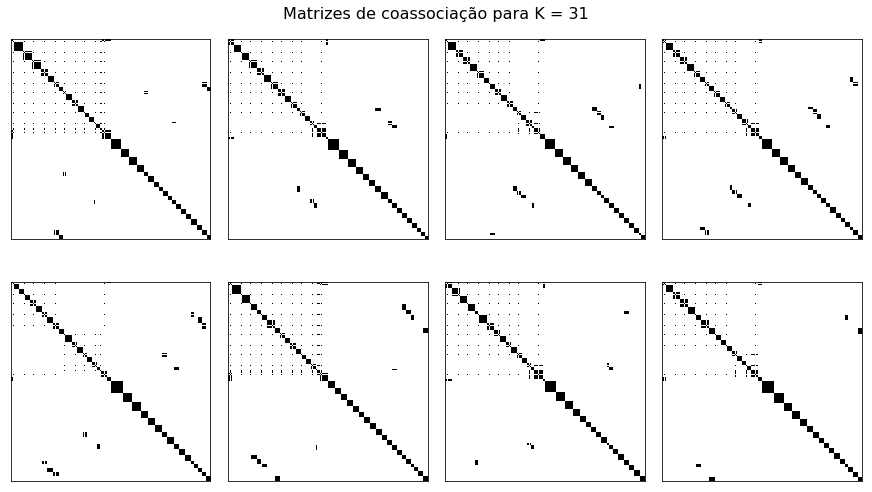

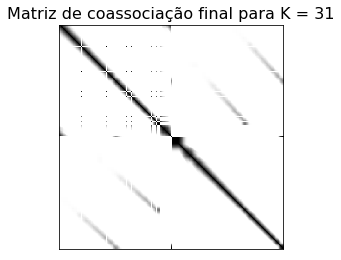

In [7]:
fixed_k_coassoc_matrix = np.zeros((len(dataset), len(dataset)))
coassoc_matrices = list()

for n, partition in enumerate(fixed_k_partitions):
    print('{:03d}/{:03d} partições processadas para Algoritmo I (K fixo)'.format(n+1, N), end='\r', flush=True)
    square_format = np.tile(partition, (len(partition), 1))
    voting = (square_format==square_format.T).astype(int)        
    if len(coassoc_matrices) < 8:
        coassoc_matrices.append(voting)
    fixed_k_coassoc_matrix += voting

coassoc_matrices = -np.array(coassoc_matrices)
plot_multiple_heatmaps(coassoc_matrices, nrows=2, ncols=4, suptitle='Matrizes de coassociação para K = {}'.format(K))

fixed_k_coassoc_matrix = 1 - fixed_k_coassoc_matrix/len(fixed_k_partitions) 
plot_single_heatmap(fixed_k_coassoc_matrix, title='Matriz de coassociação final para K = {}'.format(K))

### Algoritmo II: $N$ inicializações aleatórias com $K$ aleatório

Foi calculada a matriz de coassociação das amostras para as partições geradas pelo Algoritmo II. 

**Notas sobre a implementação**: semelhante ao Algoritmo I.

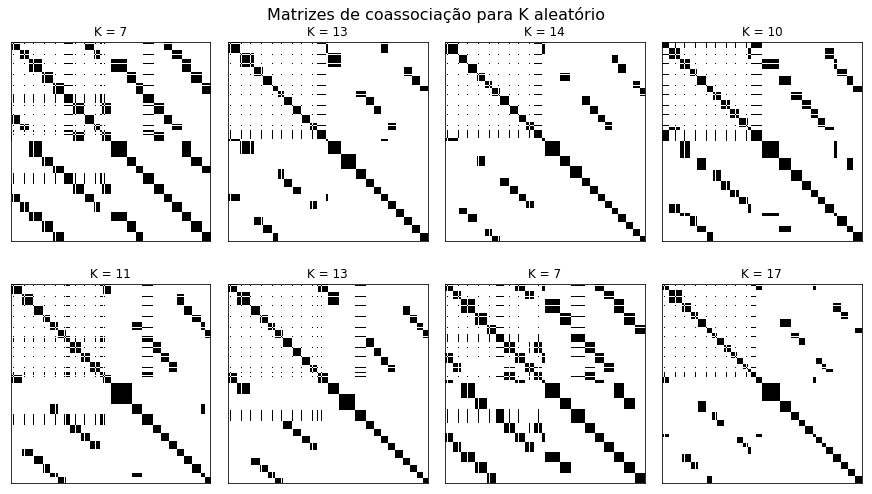

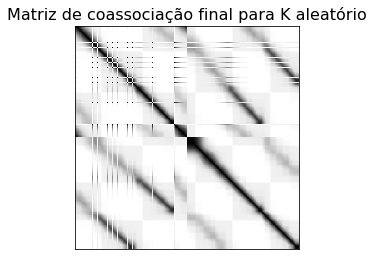

In [8]:
random_k_coassoc_matrix = np.zeros((len(dataset), len(dataset)))
coassoc_matrices = list()

for n, partition in enumerate(random_k_partitions):
    print('{:03d}/{:03d} partições processadas para Algoritmo II (K aleatório)'.format(n+1, N), end='\r', flush=True)
    square_format = np.tile(partition, (len(partition), 1))
    voting = (square_format==square_format.T).astype(int)
    if len(coassoc_matrices) < 8:
        coassoc_matrices.append(voting)
    random_k_coassoc_matrix += voting    

coassoc_matrices = -np.array(coassoc_matrices)
plot_multiple_heatmaps(coassoc_matrices, nrows=2, ncols=4, suptitle='Matrizes de coassociação para K aleatório'.format(K), subtitles=['K = {}'.format(k) for k in possible_K[:8]])

random_k_coassoc_matrix = 1 - random_k_coassoc_matrix/len(random_k_partitions) 
plot_single_heatmap(random_k_coassoc_matrix, title='Matriz de coassociação final para K aleatório')

---
## 3. _Merge_

Finalmente, na etapa de **_merge_**, é aplicado um algoritmo hierárquico sobre a matriz de coassociação para gerar o agrupamento final. Neste *notebook*, foi adotada a aplicação do *Single-link*, como em Fred & Jain [2].

Nessa etapa, é possível ter dois cenários, de acordo com o problema abordado. São eles:

1. O número de _clusters_ é previamente conhecido, ou deseja-se obter uma partição final com número de _clusters_ pré-estabelecido. A principal tarefa do método é encontrar a estrutura;

2. O número de _clusters_ é desconhecido. O método deve não só descobrir a estrutura de _clusters_ presente nos dados, como também quantos _clusters_ tem a partição que melhor representa os dados.

Nas células seguintes, cada um dos cenários são abordados individualmente.

**Obs**.: é interessante perceber como as partições finais são bastante diferentes entre os Algoritmos I e II, mostrando o impacto que uma decisão na etapa de _split_ pode causar.

### Cenário 1: Número conhecido de _clusters_

Neste cenário, é sabido o número de _clusters_ que a partição final deve possuir. Este valor passa a ser então um dos parâmetros do algoritmo hierárquico.

Para cada algoritmo da etapa de *split*, foram geradas e exibidas partições com número de _cluster_ variando no intervalo $[2, 10]$.

**Nota de implementação**: ao contrário de como foi utilizada no _notebook_ **Algoritmos de Agrupamento e Validação**, a classe `AgglomerativeClustering`, da biblioteca `sklearn`, pode receber como entrada uma matriz de distâncias (neste experimento, a matriz de coassociação). Para isso, é necessário instanciar um objeto da classe com o parâmetro `affinity='precomputed'`, fornecendo apenas a matriz de distância para os métodos `AgglomerativeClustering.fit()` ou `AgglomerativeClustering.fit_predict()`.

#### Algoritmo I: $N$ inicializações aleatórias com $K$ fixo

O algoritmo _Single-link_ foi aplicado sobre a matriz de coassociação do Algoritmo I com quantidades diferentes de _clusters_. 

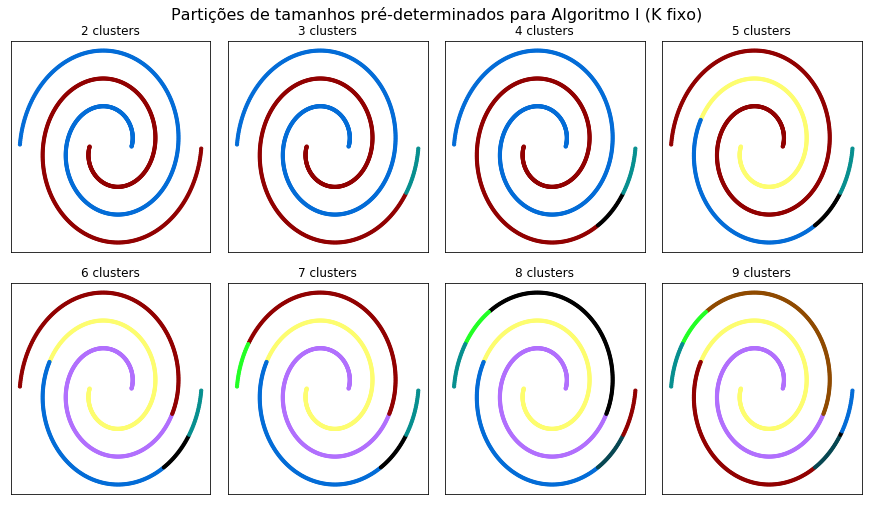

In [9]:
cluster_sizes = range(2, 10)
cluster_labels = list()

for n_clusters in cluster_sizes:
    model = AgglomerativeClustering(n_clusters=n_clusters, affinity='precomputed', linkage='single')
    cluster_labels.append(model.fit_predict(fixed_k_coassoc_matrix))    
plot_multiple_partitions(dataset[['d1', 'd2']], cluster_labels, nrows=2, ncols=4, 
                         suptitle='Partições de tamanhos pré-determinados para Algoritmo I (K fixo)', 
                         subtitles=['{} clusters'.format(c) for c in cluster_sizes])

#### Algoritmo II: $N$ inicializações aleatórias com $K$ aleatório

O algoritmo _Single-link_ foi aplicado sobre a matriz de coassociação do Algoritmo II com quantidades diferentes de _clusters_. 

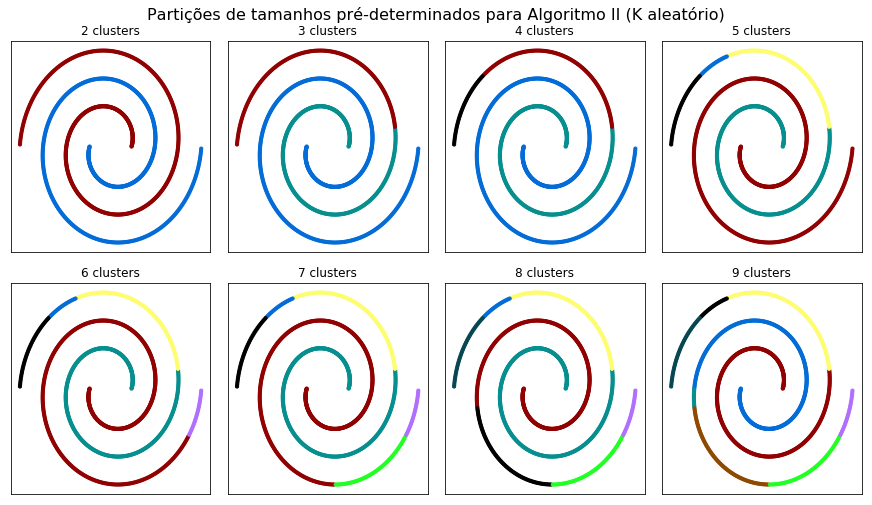

In [10]:
cluster_sizes = range(2, 10)
cluster_labels = list()

for n_clusters in cluster_sizes:
    model = AgglomerativeClustering(n_clusters=n_clusters, affinity='precomputed', linkage='single')
    cluster_labels.append(model.fit_predict(random_k_coassoc_matrix))    
plot_multiple_partitions(dataset[['d1', 'd2']], cluster_labels, nrows=2, ncols=4, 
                         suptitle='Partições de tamanhos pré-determinados para Algoritmo II (K aleatório)',
                         subtitles=['{} clusters'.format(c) for c in cluster_sizes])

### Cenário 2: Número desconhecido de _clusters_

Neste cenário, mais comum em problemas reais, o número de _clusters_ é desconhecido. Dessa forma, certas táticas podem ser utilizadas para definir o tamanho da partição final.

Em seus trabalhos, Fred & Jain propuseram duas maneiras de gerar a partição final. Em Fred & Jain [2], é sugerido adotar um valor $t$ que cortará o dendrograma gerado pelo algoritmo hierárquico. Já em Fred & Jain [3], é apresentado o conceito de _tempo de vida_ de um agrupamento no dendrograma, cortando-o de acordo com o valor do maior _tempo de vida_. Ambas as maneiras encontram-se explicadas e implementadas nas células seguintes.

### Usando diferentes valores de $t$ como corte do dendrograma

Esta maneira de decidir a quantidade de _clusters_ da partição foi sugerida em [2]. Nela, um valor $t$ é escolhido para cortar o dendrograma construído pelo algoritmo hierárquico.

Na prática, todos os pares de amostra com uma distância menor que $t$ são agrupados num mesmo _cluster_. Caso ambas as amostras já façam parte de outros *clusters*, os mesmos são combinados. Desta forma, quanto menor o valor de $t$, mais restritivo o algoritmo fica para agrupar amostras (e quanto maior o valor de $t$, mais propenso fica o algoritmo para o agrupamento).

Para cada um dos Algoritmos da etapa de *split*, foram realizados 8 cortes no dendrograma do _Single-link_. Os valores de $t$ foram escolhidos subjetivamente, para demonstrar diversas partições diferentes que podem ser geradas e o impacto de $t$ sobre isso.

**Nota de implementação**: novamente, é possível utilizar a classe `AgglomerativeClustering` da biblioteca `sklearn`. Para que funcione da maneira desejada, é necessário instanciar um objeto da classe com parâmetros `n_clusters=None` e `distance_threshold=t`. Adicionalmente, assim como no cenário 1, é necessário definir `affinity='precomputed'` e que a matriz de coassociação seja passada para `fit` ou `fit_predict`.

#### Algoritmo I: $N$ inicializações aleatórias com $K$ fixo

O algoritmo _Single-link_ foi aplicado sobre a matriz de coassociação do Algoritmo I com diferentes valores de $t$ como _threshold_.

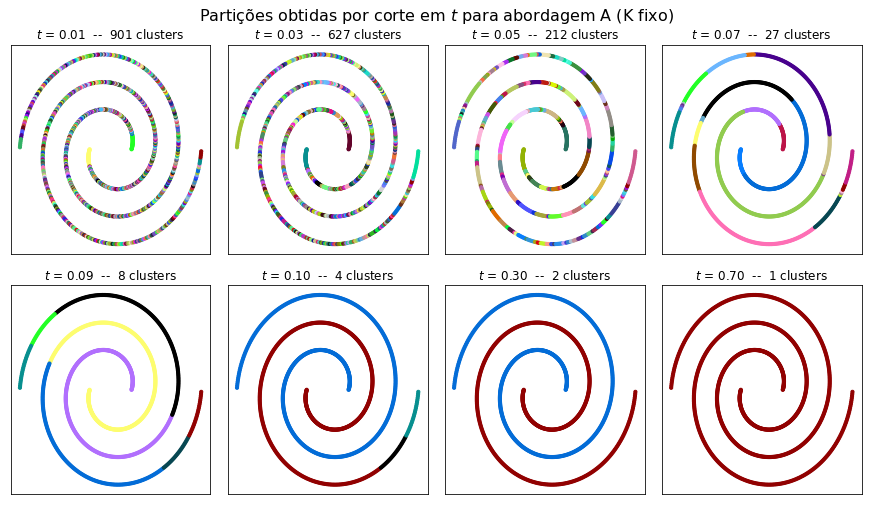

In [11]:
t_vals = [0.01, 0.03, 0.05, 0.07,0.09, 0.1, 0.3, 0.7]
cluster_labels = list()
for t in t_vals:
    model = AgglomerativeClustering(n_clusters=None, affinity='precomputed', linkage='single', distance_threshold=t)
    cluster_labels.append(model.fit_predict(fixed_k_coassoc_matrix))    
plot_multiple_partitions(dataset[['d1', 'd2']], cluster_labels, nrows=2, ncols=4, 
                         suptitle='Partições obtidas por corte em $t$ para abordagem A (K fixo)',
                         subtitles=['$t$ = {:0.2f}  --  {} clusters'.format(t, len(np.unique(c))) 
                                    for t, c in zip(t_vals, cluster_labels)])

#### Algoritmo II: $N$ inicializações aleatórias com $K$ aleatório

O algoritmo _Single-link_ foi aplicado sobre a matriz de coassociação do Algoritmo II com diferentes valores de $t$ como _threshold_.

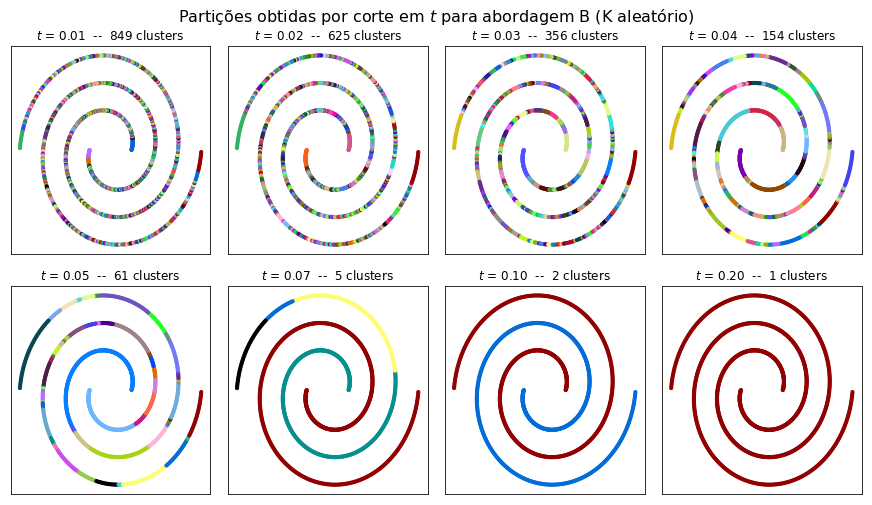

In [12]:
t_vals = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.2]
cluster_labels = list()
for t in t_vals:
    model = AgglomerativeClustering(n_clusters=None, affinity='precomputed', linkage='single', distance_threshold=t)
    cluster_labels.append(model.fit_predict(random_k_coassoc_matrix))    
plot_multiple_partitions(dataset[['d1', 'd2']], cluster_labels, nrows=2, ncols=4, 
                         suptitle='Partições obtidas por corte em $t$ para abordagem B (K aleatório)',
                         subtitles=['$t$ = {:0.2f}  --  {} clusters'.format(t, len(np.unique(c))) 
                                    for t, c in zip(t_vals, cluster_labels)])

### Encontrando o número de _clusters_ através do _Tempo de Vida_

Ainda que não seja informado diretamente o número de *clusters*, a abordagem anterior continua bastante subjetiva, visto que o pesquisador deve decidir manualmente um valor para $t$.

Para contornar esta situação, foi apresentado em Fred & Jain [3] o conceito de *tempo de vida*, uma métrica que permite a seleção do número de _clusters_ da partição final de forma automática.

#### O que é o *Tempo de Vida* (*lifetime*)?

O _Tempo de vida_ de $k$-*clusters*, ou _lifetime_ [3], é a diferença entre os valores de _threshold_ no dendrograma que geram a identificação de $k$ grupos.

Através dos dendrogramas abaixo, gerados pelo _Single-link_ nos Algoritmos I e II, é possível entender mais facilmente este conceito.

Para 2-*clusters*, por exemplo, o _tempo de vida_ é a diferença entre os valores de distância do momento em que o dendrograma deixou de ter 3 _clusters_ para ter 2, e o momento que estes 2 _clusters_ se tornarão 1.

- **Algoritmo I**: no dendrograma do algoritmo I, tem-se que 3 grupos viraram 2 com uma distância de corte de aproximadamente $0,1$ (eixo y). Estes mesmos 2 _clusters_ se conectaram com uma distância de aproximadamente $0,5$. Sendo assim, tem-se que o _tempo de vida_ de 2-_clusters_ para este dendrograma é aproximadamente $0,4$ $(0,5 - 0,1)$.

- **Algoritmo II**: no dendrograma do algoritmo II, os valores mudam significativamente. O dendrograma passou a apresentar apenas 2 _clusters_ em uma distância de aproximadamente $0,08$, que foram conectados com a distância em aproximadamente $0,11$. Assim, tem-se $0,03$ $(0,11 - 0,08)$ como _tempo de vida_ de 2-_clusters_.

Pode-se dizer que, quanto mais longa a "linha" do agrupamento no dendrograma, maior é seu tempo de vida.

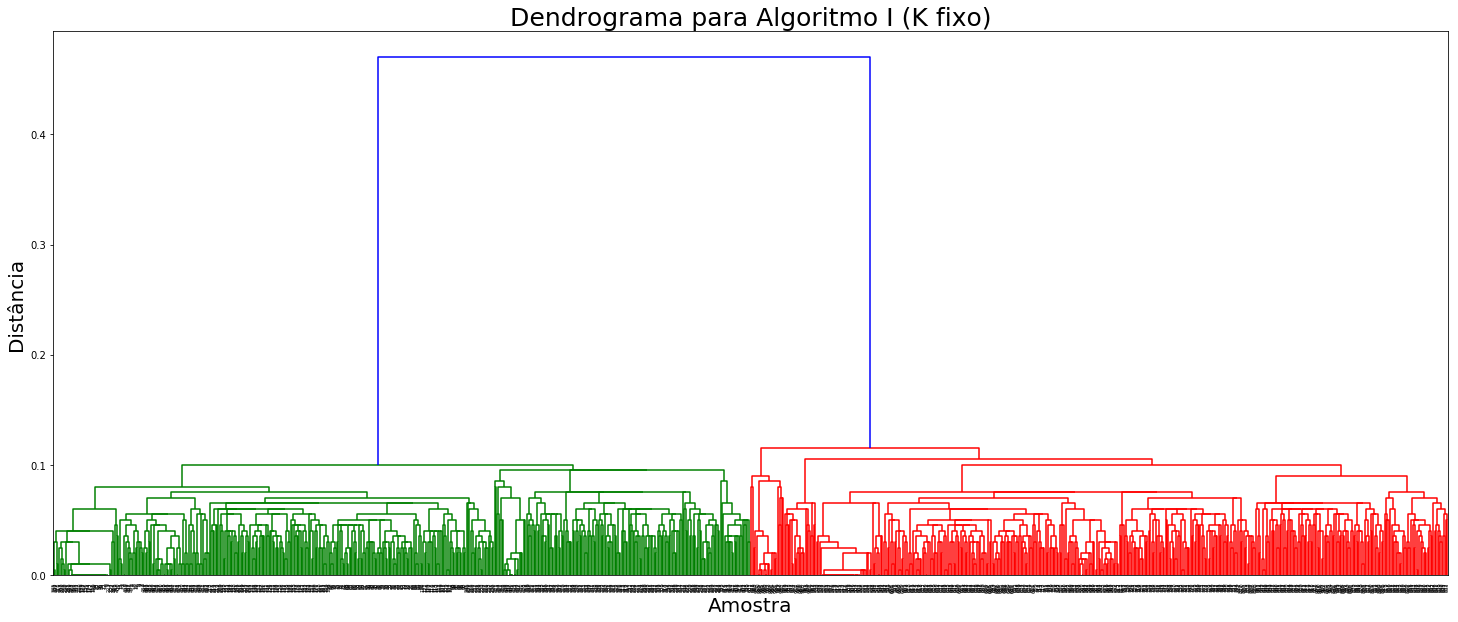

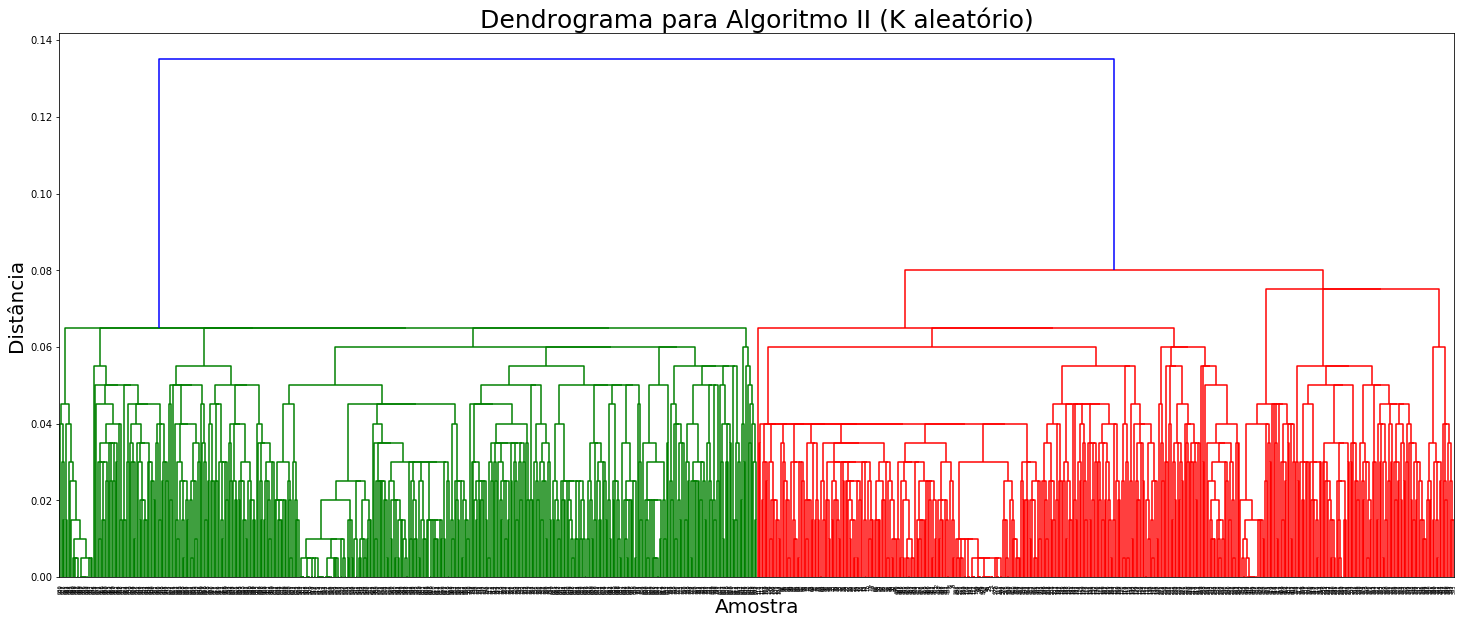

In [13]:
fixed_k_Z = linkage(squareform(fixed_k_coassoc_matrix), 'single')
plt.figure(figsize=(25, 10))
plt.title('Dendrograma para Algoritmo I (K fixo)', fontsize=25)
plt.xlabel('Amostra', fontsize=20)
plt.ylabel('Distância', fontsize=20)
dendrogram(fixed_k_Z)
plt.show()

random_k_Z = linkage(squareform(random_k_coassoc_matrix), 'single')
plt.figure(figsize=(25, 10))
plt.title('Dendrograma para Algoritmo II (K aleatório)', fontsize=25)
plt.xlabel('Amostra', fontsize=20)
plt.ylabel('Distância', fontsize=20)
dendrogram(random_k_Z)
plt.show()

#### Utilizando o _Tempo de Vida_

Para calcular o _tempo de vida_ de cada $k$-*cluster*, é necessário calcular as diferenças nas distâncias entre cada agrupamento.

Com todos os _tempos de vida_ calculados, é esperado que o maior entre eles seja aquele do verdadeiro número de estruturas nos dados.

Para a base `spirals`, em ambos os Algoritmos da etapa de *split*, o maior _tempo de vida_ foi para a partição de 2 *clusters*, o que é condizente com a quantidade de estruturas reais.

**Nota de implementação**: através da função `scipy.cluster.hierarchy.linkage()`, é possível obter o agrupamento hierárquico representado como uma matriz de ligação. Esta matriz de ligação possui dimensões $(n-1)$ x $4$. Cada linha da matriz corresponde a uma junção de _clusters_ (uma etapa) do algoritmo hierárquico. As duas primeiras colunas armazenam os identificadores dos _clusters_ que estão sendo unidos, enquanto a terceira coluna armazena a distância em que a junção foi realizada. Para obter o *tempo de vida*, é necessário calcular a diferença linha-a-linha sobre esta terceira coluna, o que pode ser obtido facilmente através da função `numpy.diff()`.

Algoritmo I (K fixo)
	Maior tempo de vida: 0.355 (threshold do dendrograma entre 0.115 e 0.470)
	Índice do corte: 998
	Número de clusters estimado: 2

-----

Algoritmo II (K aleatório)
	Maior tempo de vida: 0.055 (threshold do dendrograma entre 0.080 e 0.135)
	Índice do corte: 998
	Número de clusters estimado: 2

-----



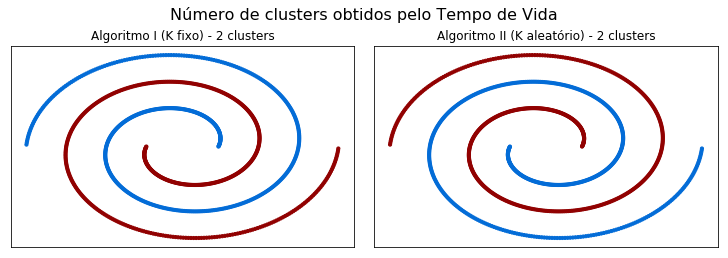

In [14]:
fixed_k_lifetimes = np.diff(fixed_k_Z[:, 2])
max_lifetime_value = np.max(fixed_k_lifetimes)
max_lifetime_index = np.argmax(fixed_k_lifetimes) + 1
fixed_k_n_clusters = len(dataset) - max_lifetime_index
print('Algoritmo I (K fixo)')
print('\tMaior tempo de vida: {:.3f} (threshold do dendrograma entre {:.3f} e {:.3f})'.format(
    max_lifetime_value, fixed_k_Z[max_lifetime_index-1, 2], fixed_k_Z[max_lifetime_index, 2]))
print('\tÍndice do corte: {}'.format(max_lifetime_index))
print('\tNúmero de clusters estimado: {}'.format(fixed_k_n_clusters))

print('\n-----\n')

random_k_lifetimes = np.diff(random_k_Z[:, 2])
max_lifetime_value = np.max(random_k_lifetimes)
max_lifetime_index = np.argmax(random_k_lifetimes) + 1
random_k_n_clusters = len(dataset) - max_lifetime_index
print('Algoritmo II (K aleatório)')
print('\tMaior tempo de vida: {:.3f} (threshold do dendrograma entre {:.3f} e {:.3f})'.format(
    max_lifetime_value, random_k_Z[max_lifetime_index-1, 2], random_k_Z[max_lifetime_index, 2]))
print('\tÍndice do corte: {}'.format(max_lifetime_index))
print('\tNúmero de clusters estimado: {}'.format(random_k_n_clusters))

print('\n-----\n')

fixed_k_model = AgglomerativeClustering(fixed_k_n_clusters, affinity='precomputed', linkage='single')
fixed_k_cluster_labels = fixed_k_model.fit_predict(fixed_k_coassoc_matrix)

random_k_model = AgglomerativeClustering(random_k_n_clusters, affinity='precomputed', linkage='single')
random_k_cluster_labels = random_k_model.fit_predict(random_k_coassoc_matrix)

plot_multiple_partitions(
    dataset[['d1', 'd2']], 
    cluster_labels=[fixed_k_cluster_labels, random_k_cluster_labels],
    nrows=1, ncols=2, 
    suptitle='Número de clusters obtidos pelo Tempo de Vida',
    subtitles=[
        'Algoritmo I (K fixo) - {} clusters'.format(fixed_k_n_clusters), 
        'Algoritmo II (K aleatório) - {} clusters'.format(random_k_n_clusters)
    ]
)

## Conclusão

Neste *notebook*, foi aplicada a técnica de **Evidence Accumulation-based Clustering (EAC)** sobre a base de dados `spirals`.

Inicialmente, múltiplas versões do algoritmo K-Médias foram aplicadas sobre a base, gerando diversas partições diferentes. Na sequência, uma matriz de coassociação de amostras foi calculada. Finalmente, um algoritmo hierárquico (*Single-link*) foi executado sobre a matriz de coassociação, gerando a partição final.

Os resultados foram bastante interessantes. Foi visto no começo do _notebook_ que o K-Médias por si só não é capaz de encontrar as estruturas reais do conjunto de dados `spirals`. Entretanto, quando utilizado dentro da **EAC**, as estruturas foram perfeitamente descobertas.

Ao término deste experimento, espera-se que o leitor tenha entendido com clareza a **EAC**, uma das diversas técnicas e métodos que caracterizam Modelos Múltiplos Descritivos. Também é esperado que a importância de tais técnicas tenha sido transmitida, demonstrando como a junção de métodos de agrupamentos com características diferentes pode gerar resultados ainda melhores do que os mesmos aplicados individualmente.

---
---
## Explore o *notebook*!

Agora é sua vez! Retorne ao começo deste _notebook_ e faça mudanças nos códigos para aprender ainda mais sobre modelos múltiplos descritivos e *Evidence Accumulation-base Clustering*!

A seguir, algumas ideias de mudanças são sugeridas...

### Teste outros algoritmos hierárquicos

No experimento, foi executado o _Single-link_ sobre a matriz de coassociação, entretanto, qualquer outro algoritmo hierárquico pode ser utilizado. Será que os resultados serão os mesmos de quando aplicado o _Single-link_?

Fred & Jain [3] também utilizaram o _Average-link_. Adicionalmente, a biblioteca `sklearn` possui implementações dos métodos _Complete-link_ e _Ward_.

Todos os métodos hierárquicos podem ser executados através da classe `AgglomerativeClustering`, apenas alterando o parâmetro `linkage` entre `{'ward', 'complete', 'average', 'single'}`.

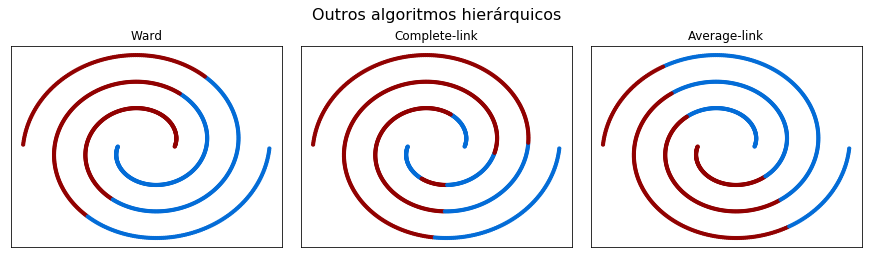

In [15]:
from sklearn.cluster import AgglomerativeClustering

spirals = load_dataset('spirals')

models = [
    AgglomerativeClustering(n_clusters=2, linkage='ward'),
    AgglomerativeClustering(n_clusters=2, linkage='complete'),
    AgglomerativeClustering(n_clusters=2, linkage='average'),    
]

cluster_labels = list()
for model in models:
    cluster_labels.append(model.fit_predict(spirals[['d1', 'd2']]))
    
plot_multiple_partitions(
    spirals[['d1', 'd2']], cluster_labels=cluster_labels, 
    nrows=1, ncols=3, suptitle='Outros algoritmos hierárquicos', 
    subtitles=['Ward', 'Complete-link', 'Average-link']
)

### Teste outros métodos de agrupamento no lugar do K-Médias

A escolha do K-Médias se deu devido a sua simplicidade e baixo esforço computacional. Será que executando outros métodos, os resultados seriam os mesmos?

Teste métodos com estratégias de agrupamento diferentes! Algumas sugestões, presentes na biblioteca `scikit-learn` são:
- `Affinity Propagation`: baseado em grafo. Embora não permita a escolha do número de *clusters*, é possível alterar o valor do parâmetro `damping` (entre $0,5$ e $1$) para gerar partições diferentes entre si;
- `Birch`: baseado em árvore. Permite a escolha do número de _clusters_ através de `n_clusters`;
- `Mean-Shift`: baseado em distância entre amostras. Embora não permita a escolha do número de *clusters*, é possível alterar o valor do parâmetro `bandwidth` para gerar partições diferentes entre si;
- `Spectral Clustering`: baseado em grafo. Permite a escolha do número de _clusters_ através de `n_clusters`;

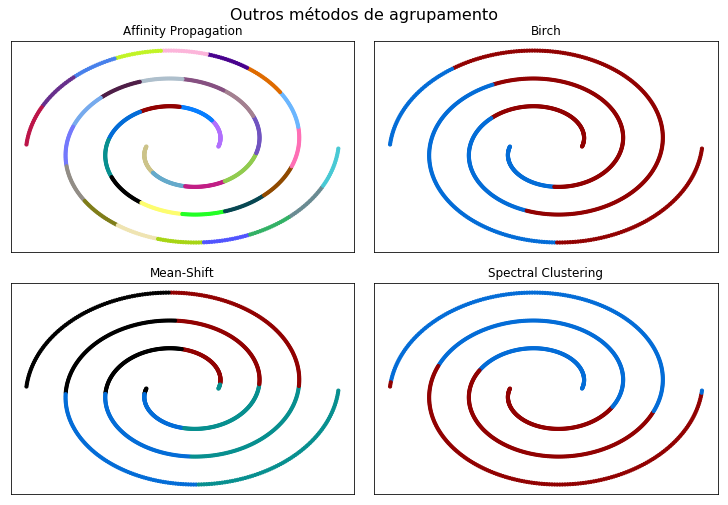

In [16]:
from sklearn.cluster import AffinityPropagation, Birch, MeanShift, SpectralClustering

spirals = load_dataset('spirals')

models = [
    AffinityPropagation(damping=0.75),
    Birch(n_clusters=2),
    MeanShift(bandwidth=3),
    SpectralClustering(n_clusters=2)
]

cluster_labels = list()
for model in models:
    cluster_labels.append(model.fit_predict(spirals[['d1', 'd2']]))
    
plot_multiple_partitions(
    spirals[['d1', 'd2']], cluster_labels=cluster_labels, 
    nrows=2, ncols=2, suptitle='Outros métodos de agrupamento', 
    subtitles=['Affinity Propagation', 'Birch', 'Mean-Shift', 'Spectral Clustering']
)

### Teste com bases de dados diferentes

Foi visto que o resultado obtido sobre a base `spirals` encontrou com perfeição as estruturas reais do conjunto. Será que isso é verdade para qualquer base de dados?

No diretório `datasets`, encontram-se outros conjuntos de dados cujo K-Médias não consegue encontrar as partições reais se aplicado individualmente. São elas `monkeys.csv`, `ds2c2sc13_5.csv` e `ds2c2sc13_13.csv`.

Execute os experimentos acima novamente, alterando a base de dados de entrada. Veja como se comportam as matrizes de coassociação e as partições finais obtidas. Será que, assim como com na base `spirals`, o resultado final encontrado pelo _tempo de vida_ será o mesmo para ambos os Algoritmos?

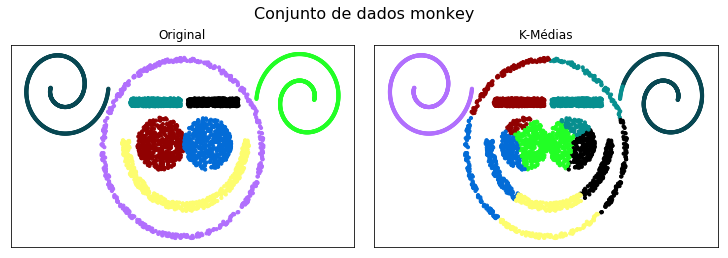

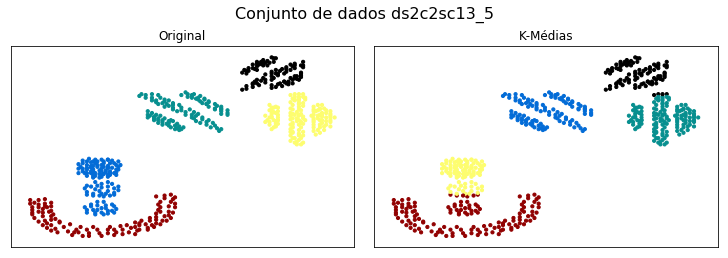

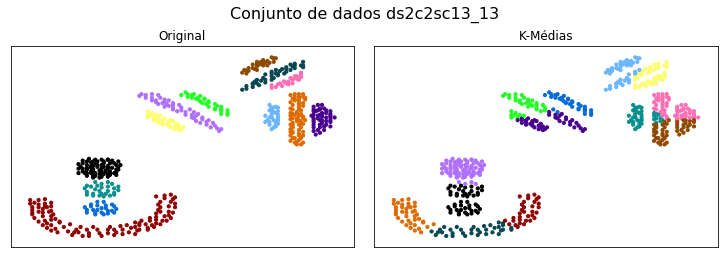

In [17]:
monkey = load_dataset('monkey')
ds2c2sc13_5 = load_dataset('ds2c2sc13_5')
ds2c2sc13_13 = load_dataset('ds2c2sc13_13')

for dataset in [monkey, ds2c2sc13_5, ds2c2sc13_13]:
    model = KMeans(n_clusters=dataset.n_clusters)
    kmean_clusters = model.fit_predict(dataset[['d1', 'd2']])
    plot_multiple_partitions(
        dataset[['d1', 'd2']], cluster_labels=[dataset['cluster'], kmean_clusters], 
        nrows=1, ncols=2, suptitle='Conjunto de dados {}'.format(dataset.name), 
        subtitles=['Original', 'K-Médias']
    )

---
---
## Referências

[1] Figueiredo, M. and Jain, A. K. "Unsupervised learning of finite mixture models," in *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 24, no. 3, 2002, pp. 381 - 396. DOI: 10.1109/34.990138. URL: https://ieeexplore.ieee.org/document/990138

[2] Fred, A. L. N. and Jain, A. K. "Data clustering Using Evidence Accumulation," in *Proceedings of the 16th International Conference on Pattern Recognition (ICPR 2002)*, Québec City, Canada, 2002, pp. 276 - 280. DOI: 10.1109/ICPR.2002.1047450. URL: https://ieeexplore.ieee.org/document/1047450

[3] Fred, A. L. N. and Jain, A. K. "Combining multiple clusterings using Evidence Accumulation," in *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 27, no. 6, 2005, pp. 835 - 850. DOI: 10.1109/TPAMI.2005.113. URL: https://ieeexplore.ieee.org/document/1432715